In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# GenAI-Powered Customer Feedback Insights


### Project Objective

Analyze customer feedback from Amazon and Yelp reviews using Python and GenAI-assisted analysis to identify:

- Customer sentiment
- Recurring negative pain points
- Positive customer themes
- Likely root causes
- Business priorities
- Actionable recommendations

### Data Sources

- Amazon customer reviews
- Yelp customer reviews

### Final Dataset

- Original reviews: 2,000
- Exact duplicate records removed: 14
- Final unique reviews: 1,986
- Missing values: 0
- Remaining duplicates: 0

### Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- GenAI-assisted thematic analysis

## Table of Contents

1. Project Objective
2. Data Loading and Preparation
3. Dataset Overview
4. Sentiment Analysis
5. Amazon vs Yelp Comparison
6. Data Quality and Cleaning
7. GenAI Prompt Library
8. Negative Customer Themes
9. Root Cause Analysis
10. Customer Problem Prioritization
11. Actionable Business Recommendations
12. Positive Customer Themes
13. Executive Summary
14. Final Insights and Conclusion
15. Limitations

In [5]:
import pandas as pd

In [6]:
amazon_df = pd.read_csv(
    "../data/amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["feedback_text", "sentiment_label"]
)

In [7]:
amazon_df.head()

,feedback_text,sentiment_label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [8]:
yelp_df = pd.read_csv(
    "../data/yelp_labelled.txt",
    sep="\t",
    header=None,
    names=["feedback_text", "sentiment_label"]
)

In [9]:
yelp_df.head()

,feedback_text,sentiment_label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [10]:
amazon_df["source"] = "Amazon"

In [11]:
yelp_df["source"] = "Yelp"

In [12]:
feedback_df = pd.concat(
    [amazon_df, yelp_df],
    ignore_index=True
)

In [13]:
feedback_df.head()

,feedback_text,sentiment_label,source
0,So there is no way for me to plug it in here i...,0,Amazon
1,"Good case, Excellent value.",1,Amazon
2,Great for the jawbone.,1,Amazon
3,Tied to charger for conversations lasting more...,0,Amazon
4,The mic is great.,1,Amazon


In [14]:
print("Total reviews:", len(feedback_df))

Total reviews: 2000


In [15]:
print("Amazon reviews:", len(amazon_df))
print("Yelp reviews:", len(yelp_df))

Amazon reviews: 1000
Yelp reviews: 1000


In [16]:
print("Negative reviews:", (feedback_df["sentiment_label"] == 0).sum())
print("Positive reviews:", (feedback_df["sentiment_label"] == 1).sum())

Negative reviews: 1000
Positive reviews: 1000


In [17]:
sentiment_counts = feedback_df["sentiment_label"].value_counts()

print(sentiment_counts)

sentiment_label
0    1000
1    1000
Name: count, dtype: int64


In [18]:
feedback_df["sentiment"] = feedback_df["sentiment_label"].map({
    0: "Negative",
    1: "Positive"
})

In [19]:
feedback_df.head()

,feedback_text,sentiment_label,source,sentiment
0,So there is no way for me to plug it in here i...,0,Amazon,Negative
1,"Good case, Excellent value.",1,Amazon,Positive
2,Great for the jawbone.,1,Amazon,Positive
3,Tied to charger for conversations lasting more...,0,Amazon,Negative
4,The mic is great.,1,Amazon,Positive


In [20]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt

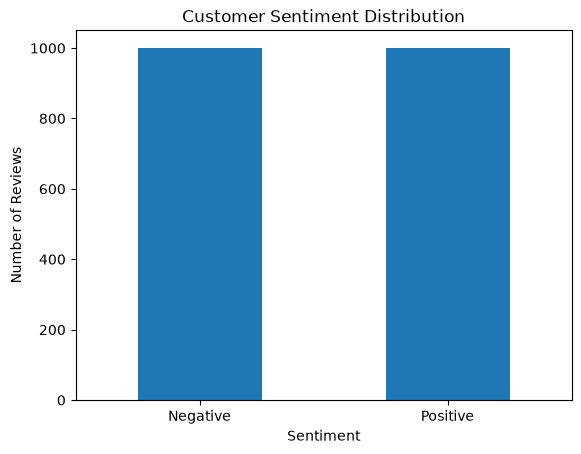

In [22]:
feedback_df["sentiment"].value_counts().plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [23]:
source_sentiment = pd.crosstab(
    feedback_df["source"],
    feedback_df["sentiment"]
)

source_sentiment

sentiment,Negative,Positive
source,,
Amazon,500,500
Yelp,500,500


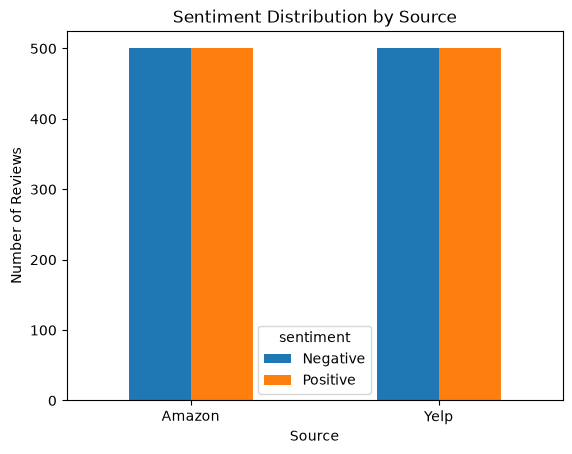

In [24]:
source_sentiment.plot(kind="bar")

plt.title("Sentiment Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [25]:
negative_reviews = feedback_df[
    feedback_df["sentiment"] == "Negative"
]

negative_reviews[["feedback_text", "source"]].head(20)

,feedback_text,source
0,So there is no way for me to plug it in here i...,Amazon
3,Tied to charger for conversations lasting more...,Amazon
5,I have to jiggle the plug to get it to line up...,Amazon
6,If you have several dozen or several hundred c...,Amazon
8,"Needless to say, I wasted my money.",Amazon
9,What a waste of money and time!.,Amazon
12,If the two were seperated by a mere 5+ ft I st...,Amazon
14,"The design is very odd, as the ear ""clip"" is n...",Amazon
16,I advise EVERYONE DO NOT BE FOOLED!,Amazon
19,It clicks into place in a way that makes you w...,Amazon


In [26]:
positive_reviews = feedback_df[
    feedback_df["sentiment"] == "Positive"
]

positive_reviews[["feedback_text", "source"]].head(20)

,feedback_text,source
1,"Good case, Excellent value.",Amazon
2,Great for the jawbone.,Amazon
4,The mic is great.,Amazon
7,If you are Razr owner...you must have this!,Amazon
10,And the sound quality is great.,Amazon
11,He was very impressed when going from the orig...,Amazon
13,Very good quality though,Amazon
15,Highly recommend for any one who has a blue to...,Amazon
17,So Far So Good!.,Amazon
18,Works great!.,Amazon


In [27]:
feedback_df.to_csv(
    "../data/capstone_customer_feedback.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [28]:
summary_table = pd.crosstab(
    feedback_df["source"],
    feedback_df["sentiment"]
)

summary_table

sentiment,Negative,Positive
source,,
Amazon,500,500
Yelp,500,500


In [29]:
print("PROJECT DATASET SUMMARY")
print("=" * 40)
print("Total reviews:", len(feedback_df))
print("Amazon reviews:", len(amazon_df))
print("Yelp reviews:", len(yelp_df))
print("Negative reviews:", (feedback_df["sentiment"] == "Negative").sum())
print("Positive reviews:", (feedback_df["sentiment"] == "Positive").sum())
print("Missing values:", feedback_df.isnull().sum().sum())
print("Duplicate rows:", feedback_df.duplicated().sum())

PROJECT DATASET SUMMARY
Total reviews: 2000
Amazon reviews: 1000
Yelp reviews: 1000
Negative reviews: 1000
Positive reviews: 1000
Missing values: 0
Duplicate rows: 14


In [30]:
duplicates = feedback_df[
    feedback_df.duplicated(keep=False)
].sort_values("feedback_text")

duplicates

,feedback_text,sentiment_label,source,sentiment
446,Does not fit.,0,Amazon,Negative
748,Does not fit.,0,Amazon,Negative
180,Don't buy this product.,0,Amazon,Negative
543,Don't buy this product.,0,Amazon,Negative
402,Excellent product for the price.,1,Amazon,Positive
892,Excellent product for the price.,1,Amazon,Positive
792,Great Phone.,1,Amazon,Positive
290,Great Phone.,1,Amazon,Positive
285,Great phone!.,1,Amazon,Positive
187,Great phone!.,1,Amazon,Positive


In [31]:
feedback_clean = feedback_df.drop_duplicates().copy()

print("Original reviews:", len(feedback_df))
print("Duplicate rows removed:", len(feedback_df) - len(feedback_clean))
print("Clean reviews:", len(feedback_clean))

Original reviews: 2000
Duplicate rows removed: 14
Clean reviews: 1986


In [32]:
print("Remaining duplicate rows:", feedback_clean.duplicated().sum())
print("Missing values:", feedback_clean.isnull().sum().sum())

Remaining duplicate rows: 0
Missing values: 0


In [33]:
feedback_clean.to_csv(
    "../data/capstone_customer_feedback_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [34]:
negative_clean = feedback_clean[
    feedback_clean["sentiment"] == "Negative"
].copy()

print("Negative reviews:", len(negative_clean))

Negative reviews: 994


In [35]:
negative_clean["source"].value_counts()

source
Amazon    497
Yelp      497
Name: count, dtype: int64

In [36]:
negative_clean[
    ["feedback_text", "source"]
].to_csv(
    "../data/negative_reviews_for_genai.csv",
    index=False
)

print("Negative reviews file created successfully!")

Negative reviews file created successfully!


# GenAI Prompt Library

## Prompt 1 — Negative Theme Extraction

Analyze the provided customer reviews and identify the 5–8 most recurring negative themes.

For each theme provide:
1. Theme name
2. Short description
3. Representative review evidence
4. Likely customer pain point
5. Likely root cause
6. Business impact
7. Recommended business action

Do not invent information that is not supported by the reviews.
If evidence is insufficient, explicitly state that.

---

## Prompt 2 — Positive Theme Extraction

Analyze the provided positive customer reviews and identify the 5–8 most recurring positive themes.

For each theme provide:
1. Theme name
2. What customers appreciate
3. Representative review evidence
4. Likely customer value
5. Business implication
6. Recommendation for maintaining or expanding this strength

Do not invent information that is not supported by the reviews.

---

## Prompt 3 — Root Cause Analysis

For each major negative customer theme, analyze the likely root cause.

Separate:
- Customer-visible problem
- Possible underlying cause
- Evidence from reviews
- Confidence level

Do not claim a root cause as fact unless the reviews provide sufficient evidence.
Clearly label reasonable inference as inference.

---

## Prompt 4 — Business Impact Analysis

Analyze the major negative customer themes and explain their potential business impact.

Consider:
- Customer satisfaction
- Repeat purchase or return intention
- Customer retention
- Brand reputation
- Operational efficiency
- Revenue or cost implications

Use only evidence-supported reasoning and clearly identify assumptions.

---

## Prompt 5 — Prioritize Customer Problems

Rank the major negative themes using:

Priority = Frequency × Customer Impact × Business Impact

For each theme provide:
- Frequency/evidence
- Customer impact
- Business impact
- Priority level
- Reason for ranking

Explain the assumptions used in the ranking.

---

## Prompt 6 — Actionable Recommendations

Based on the identified customer themes, create practical business recommendations.

For each recommendation provide:
- Problem addressed
- Recommended action
- Why the action may help
- Expected customer benefit
- Suggested business owner/team
- Suggested success metric

Recommendations must be realistic and directly connected to evidence from the reviews.

# GenAI Prompt Library

## Prompt 1 — Negative Theme Extraction

Analyze the provided customer reviews and identify the 5–8 most recurring negative themes.

For each theme provide:
1. Theme name
2. Short description
3. Representative review evidence
4. Likely customer pain point
5. Likely root cause
6. Business impact
7. Recommended business action

Do not invent information that is not supported by the reviews.
If evidence is insufficient, explicitly state that.

---

## Prompt 2 — Positive Theme Extraction

Analyze the provided positive customer reviews and identify the 5–8 most recurring positive themes.

For each theme provide:
1. Theme name
2. What customers appreciate
3. Representative review evidence
4. Likely customer value
5. Business implication
6. Recommendation for maintaining or expanding this strength

Do not invent information that is not supported by the reviews.

---

## Prompt 3 — Root Cause Analysis

For each major negative customer theme, analyze the likely root cause.

Separate:
- Customer-visible problem
- Possible underlying cause
- Evidence from reviews
- Confidence level

Do not claim a root cause as fact unless the reviews provide sufficient evidence.
Clearly label reasonable inference as inference.

---

## Prompt 4 — Business Impact Analysis

Analyze the major negative customer themes and explain their potential business impact.

Consider:
- Customer satisfaction
- Repeat purchase or return intention
- Customer retention
- Brand reputation
- Operational efficiency
- Revenue or cost implications

Use only evidence-supported reasoning and clearly identify assumptions.

---

## Prompt 5 — Prioritize Customer Problems

Rank the major negative themes using:

Priority = Frequency × Customer Impact × Business Impact

For each theme provide:
- Frequency/evidence
- Customer impact
- Business impact
- Priority level
- Reason for ranking

Explain the assumptions used in the ranking.

---

## Prompt 6 — Actionable Recommendations

Based on the identified customer themes, create practical business recommendations.

For each recommendation provide:
- Problem addressed
- Recommended action
- Why the action may help
- Expected customer benefit
- Suggested business owner/team
- Suggested success metric

Recommendations must be realistic and directly connected to evidence from the reviews.

# GenAI Analysis — Negative Customer Themes

## Overview

The negative-review dataset contains 994 unique negative reviews:
- 497 Amazon reviews
- 497 Yelp reviews

The analysis identified recurring customer pain points across both sources. Because individual reviews can describe more than one issue, theme-supporting keyword counts should be treated as signals rather than exact semantic frequencies.

## Amazon — Negative Themes

### 1. Product Usability and Fit
Customers report difficulty using some products, including awkward designs, uncomfortable components, and connection or plug-related problems.

**Business implication:** Product design and usability should be reviewed to reduce customer frustration.

### 2. Audio and Call Quality
Customers report poor sound quality, static, garbled audio, poor volume and call-related problems.

**Business implication:** Hardware quality, connectivity and audio performance should be investigated.

### 3. Battery and Charging
Customers report battery problems, short battery life and products that do not hold a charge.

**Business implication:** Battery reliability and charging performance should be improved.

### 4. Product Reliability and Durability
Some customers report products stopping working or breaking after use.

**Business implication:** Product quality control and durability testing should be strengthened.

### 5. Value and Wasted Money
Some customers feel the product did not justify its price and describe the purchase as a waste of money.

**Business implication:** Product performance and customer expectations should be aligned more closely with pricing and marketing.

### 6. Customer Service and Support
Some reviews describe poor customer service or inadequate technical support.

**Business implication:** Support processes and customer-service responsiveness should be reviewed.

## Yelp — Negative Themes

### 1. Food Quality and Taste
Customers frequently complain about bland, unpleasant, poorly prepared or poor-texture food.

**Business implication:** Food preparation, ingredient quality and consistency should be investigated.

### 2. Service and Staff
Customers report slow, poor or unpleasant service and negative interactions with staff.

**Business implication:** Staff training, service standards and management oversight should be strengthened.

### 3. Waiting Time and Speed
Customers complain about long waits for service or food.

**Business implication:** Restaurant workflow, staffing and order-processing processes should be reviewed.

### 4. Value and Price
Some customers believe prices are too high compared with the quality of the experience.

**Business implication:** Pricing and perceived value should be evaluated.

### 5. Overall Customer Experience
Some negative reviews indicate that the complete experience was poor enough that customers would not return or recommend the business.

**Business implication:** Food, service and value issues should be addressed together rather than independently.

### 6. Atmosphere and Location Experience
Some customers express dissatisfaction with the overall venue or location experience.

**Business implication:** Management should evaluate environmental and location-specific factors affecting customer satisfaction.

## Key Cross-Source Insight

Amazon complaints are primarily product-oriented, focusing on usability, performance, battery, reliability and value.

Yelp complaints are primarily experience-oriented, focusing on food quality, service, waiting time, value and the overall dining experience.

This indicates that customer-feedback improvement strategies should be tailored to the type of business rather than applying one generic solution to all reviews.

# Root Cause Analysis — Negative Customer Themes

## Amazon

| Customer Problem | Evidence from Reviews | Likely Root Cause | Confidence |
|---|---|---|---|
| Product usability and fit | Reviews mention awkward designs, uncomfortable components and difficulty connecting/using products | Product design may not sufficiently account for ease of use, fit and compatibility | Medium |
| Audio and call quality | Reviews mention static, garbled sound, poor volume and call problems | Hardware quality, connectivity or audio implementation may be inconsistent | Medium |
| Battery and charging | Reviews mention poor battery life and products not holding charge | Battery capacity, battery health or charging design may not meet customer expectations | Medium |
| Reliability and durability | Reviews describe products stopping work or breaking | Product quality control or durability testing may need improvement | Medium |
| Value and wasted money | Customers describe purchases as a waste of money or not worth the price | Product performance may not match customer expectations created by price or marketing | High |
| Customer service | Reviews explicitly complain about poor customer service/support | Support process, responsiveness or service quality may be inadequate | Medium |

## Yelp

| Customer Problem | Evidence from Reviews | Likely Root Cause | Confidence |
|---|---|---|---|
| Food quality and taste | Reviews describe food as bland, unpleasant, stale or poorly prepared | Food preparation, ingredient quality or consistency may be inadequate | Medium |
| Service and staff | Reviews describe slow or unpleasant service and negative staff interactions | Staff training, staffing levels or service processes may be inadequate | Medium |
| Waiting time | Customers report long waits for food or service | Staffing, kitchen workflow or order-processing capacity may be insufficient | Medium |
| Value and price | Customers describe some experiences as overpriced or not worth the cost | Customer-perceived value may not match pricing | Medium |
| Overall experience | Some customers state they would not return or recommend the business | Multiple service, food and value problems may combine into a poor overall experience | High |
| Atmosphere/location | Some reviews criticize the venue or overall environment | Environmental or location-specific factors may not meet customer expectations | Low/Medium |

## Root Cause Interpretation

The reviews provide direct evidence of customer problems, but they do not always prove the internal business cause.

Therefore, the root causes above should be treated as **evidence-based hypotheses**, not confirmed internal causes.

Further investigation would be required to validate them using operational data such as:
- Product return and defect rates
- Battery failure rates
- Customer support tickets
- Restaurant order/wait-time data
- Staff scheduling data
- Food quality checks
- Pricing and competitor comparisons

# Customer Problem Prioritization

## Prioritization Framework

Customer problems are prioritized using three factors:

- Frequency: How frequently the issue appears in the review data
- Customer Impact: How seriously the issue affects the customer experience
- Business Impact: Potential effect on retention, reputation, revenue or operating cost

Because the review dataset does not contain direct financial or operational metrics, business-impact ratings are qualitative and should be treated as evidence-based assessments rather than measured financial values.

## Priority Matrix

| Source | Customer Problem | Frequency Signal | Customer Impact | Business Impact | Priority |
|---|---|---|---|---|---|
| Amazon | Product usability and fit | High | High | High | High |
| Amazon | Audio and call quality | High | High | High | High |
| Amazon | Battery and charging | Medium | High | High | High |
| Amazon | Reliability and durability | Medium | High | High | High |
| Amazon | Value and wasted money | Medium | High | High | High |
| Amazon | Customer service/support | Lower | Medium/High | High | Medium/High |
| Yelp | Food quality and taste | High | High | High | High |
| Yelp | Service and staff | High | High | High | High |
| Yelp | Waiting time | High | Medium/High | High | High |
| Yelp | Value and price | Medium | High | High | Medium/High |
| Yelp | Overall experience | High | High | High | High |
| Yelp | Atmosphere/location | Medium | Medium | Medium | Medium |

## Priority Interpretation

### Highest Priority — Amazon
1. Product usability and fit
2. Audio and call quality
3. Battery and charging
4. Reliability and durability
5. Value and customer expectations

### Highest Priority — Yelp
1. Food quality and taste
2. Service and staff
3. Waiting time
4. Overall customer experience
5. Value and price

## Important Limitation

These priorities are qualitative because the dataset does not provide:
- Revenue impact per complaint
- Product return data
- Customer lifetime value
- Customer churn data
- Operational cost data
- Restaurant staffing data

Therefore, the priority ranking should be validated with business and operational data before major investment decisions are made.

# Actionable Business Recommendations

## Amazon Recommendations

### 1. Improve Product Usability and Fit

**Problem addressed:** Customers report difficulty using products and problems with fit/design.

**Recommended action:** Review product ergonomics, connection procedures and compatibility. Use customer complaints to identify common usability failures and prioritize product-design improvements.

**Expected customer benefit:** Easier setup, better usability and fewer frustrating experiences.

**Suggested owner:** Product Management / Product Design / Engineering

**Success metric:** Reduction in usability-related negative reviews and support requests.

---

### 2. Improve Audio and Call Quality

**Problem addressed:** Customers report static, poor sound, garbled audio and call problems.

**Recommended action:** Investigate hardware, connectivity and audio-performance issues and strengthen quality testing before release.

**Expected customer benefit:** More reliable audio and communication performance.

**Suggested owner:** Engineering / Quality Assurance

**Success metric:** Reduction in audio- and call-quality complaints.

---

### 3. Improve Battery and Charging Reliability

**Problem addressed:** Customers report short battery life and charging problems.

**Recommended action:** Review battery capacity, charging components and battery-performance testing.

**Expected customer benefit:** Longer and more reliable usage between charges.

**Suggested owner:** Engineering / Quality Assurance

**Success metric:** Reduction in battery and charging-related complaints and returns.

---

### 4. Strengthen Product Reliability and Quality Control

**Problem addressed:** Customers report products stopping work or breaking.

**Recommended action:** Analyze failure patterns and strengthen durability testing and quality-control checks.

**Expected customer benefit:** More reliable products and greater customer confidence.

**Suggested owner:** Quality Assurance / Manufacturing / Engineering

**Success metric:** Lower defect, return and durability-related complaint rates.

---

### 5. Align Product Value With Customer Expectations

**Problem addressed:** Customers describe some purchases as a waste of money or not worth the price.

**Recommended action:** Review product performance against pricing and marketing claims to ensure customer expectations are realistic.

**Expected customer benefit:** Better perceived value and fewer purchase regrets.

**Suggested owner:** Product Management / Marketing

**Success metric:** Reduction in value-related negative reviews.

---

## Yelp Recommendations

### 6. Improve Food Quality and Consistency

**Problem addressed:** Customers report poor taste, texture and food preparation.

**Recommended action:** Establish stronger food-quality checks, standardized preparation procedures and consistency monitoring.

**Expected customer benefit:** More consistent food quality.

**Suggested owner:** Restaurant Operations / Kitchen Management

**Success metric:** Reduction in food-quality complaints.

---

### 7. Improve Service and Staff Experience

**Problem addressed:** Customers report slow or unpleasant service and negative staff interactions.

**Recommended action:** Strengthen staff training, service standards and manager oversight.

**Expected customer benefit:** Faster, more consistent and more professional service.

**Suggested owner:** Restaurant Management / Operations

**Success metric:** Reduction in service-related negative reviews.

---

### 8. Reduce Waiting Times

**Problem addressed:** Customers report long waits for food or service.

**Recommended action:** Analyze peak-period staffing, kitchen workflow and order-processing bottlenecks.

**Expected customer benefit:** Faster service and improved customer satisfaction.

**Suggested owner:** Restaurant Operations

**Success metric:** Average order/wait time and reduction in wait-time complaints.

---

### 9. Improve Perceived Value

**Problem addressed:** Customers sometimes believe the experience is overpriced.

**Recommended action:** Compare pricing with customer-perceived quality and competitor offerings and identify opportunities to improve the value proposition.

**Expected customer benefit:** Better value perception and willingness to return.

**Suggested owner:** Management / Marketing

**Success metric:** Reduction in price/value complaints and improvement in customer ratings.

---

## Overall Recommendation

The most effective improvement strategy should be source-specific.

For Amazon, management should prioritize **product usability, performance, reliability and value**.

For Yelp, management should prioritize **food quality, service, waiting time and overall customer experience**.

These recommendations should be validated against operational and financial data before implementation.

In [37]:
positive_clean = feedback_clean[
    feedback_clean["sentiment"] == "Positive"
].copy()

print("Positive reviews:", len(positive_clean))

Positive reviews: 992


In [38]:
positive_clean["source"].value_counts()

source
Yelp      499
Amazon    493
Name: count, dtype: int64

In [39]:
positive_clean[
    ["feedback_text", "source"]
].to_csv(
    "../data/positive_reviews_for_genai.csv",
    index=False
)

print("Positive reviews file created successfully!")

Positive reviews file created successfully!


# GenAI Analysis — Positive Customer Themes

## Overview

The cleaned dataset contains 992 positive reviews:
- 493 Amazon reviews
- 499 Yelp reviews

The positive reviews were analyzed to identify recurring strengths customers appreciate. Theme-supporting keyword counts are treated as signals rather than exact semantic frequencies because individual reviews may belong to multiple themes.

## Amazon — Positive Themes

### 1. Product Quality and Performance

Customers frequently describe products as great, excellent, good quality and reliable.

**Business implication:** Product quality and performance are important customer strengths and should be maintained.

### 2. Sound and Audio Quality

Customers praise sound quality, microphones, headsets and audio performance.

**Business implication:** Audio performance should remain a priority in product development and quality assurance.

### 3. Battery Performance

Customers mention extended battery life and being able to use products for several days without charging.

**Business implication:** Battery performance can be used as a product differentiator.

### 4. Compatibility and Practical Usefulness

Customers describe products as useful with their phones, computers and other devices.

**Business implication:** Compatibility and ease of practical use should continue to be emphasized.

### 5. Value for Money

Customers mention good prices, excellent value and products being worth purchasing.

**Business implication:** Maintaining a strong price-to-performance relationship can support customer satisfaction.

### 6. Recommendation and Overall Satisfaction

Some customers explicitly recommend products and describe them very positively.

**Business implication:** Positive experiences can generate word-of-mouth recommendations.

## Yelp — Positive Themes

### 1. Food Quality and Taste

Customers frequently praise food as great, amazing, delicious or tasty.

**Business implication:** Food quality and consistency should remain a core operational priority.

### 2. Service Quality

Customers praise prompt, friendly and positive service experiences.

**Business implication:** Good service standards and staff training should be maintained.

### 3. Atmosphere and Restaurant Experience

Customers describe attractive interiors and enjoyable restaurant environments.

**Business implication:** The physical environment contributes to the overall customer experience and should be maintained.

### 4. Value and Pricing

Customers mention good prices, decent deals and inexpensive experiences.

**Business implication:** Competitive pricing and perceived value contribute positively to customer satisfaction.

### 5. Menu Selection and Variety

Customers praise menu choices, food combinations and available selections.

**Business implication:** Maintaining useful variety can strengthen customer satisfaction.

### 6. Overall Positive Experience

Customers describe visits as delightful, enjoyable and recommendable.

**Business implication:** Combining good food, service, atmosphere and value creates a strong overall experience.

## Cross-Source Positive Insight

Amazon customers primarily appreciate:
- Product quality
- Performance
- Audio
- Battery life
- Compatibility
- Value

Yelp customers primarily appreciate:
- Food quality
- Service
- Atmosphere
- Menu selection
- Value
- Overall experience

The strongest strategy is therefore to preserve the existing strengths of each source while addressing the corresponding negative pain points.

# Executive Summary — Customer Feedback Insights

## Dataset

The analysis uses 1,986 unique customer reviews after removing 14 exact duplicate records.

| Category | Amazon | Yelp | Total |
|---|---:|---:|---:|
| Positive | 493 | 499 | 992 |
| Negative | 497 | 497 | 994 |
| **Total** | **990** | **996** | **1,986** |

There are no missing values and no remaining duplicate records.

## Key Negative Insights

### Amazon

The main customer pain points are:
1. Product usability and fit
2. Audio and call quality
3. Battery and charging
4. Product reliability and durability
5. Value for money
6. Customer service/support

### Yelp

The main customer pain points are:
1. Food quality and taste
2. Service and staff
3. Waiting time
4. Value and pricing
5. Overall customer experience
6. Atmosphere/location

## Key Positive Insights

### Amazon

Customers particularly appreciate:
- Product quality and performance
- Sound/audio quality
- Battery performance
- Compatibility and usefulness
- Value for money
- Overall satisfaction and recommendation potential

### Yelp

Customers particularly appreciate:
- Food quality and taste
- Service quality
- Atmosphere
- Value and pricing
- Menu selection
- Overall positive experience

## Cross-Source Business Insight

The two sources require different improvement strategies.

Amazon feedback is primarily product-oriented. Customers focus on usability, performance, reliability, battery life and value.

Yelp feedback is primarily experience-oriented. Customers focus on food quality, service, waiting time, atmosphere and value.

Therefore, a single generic customer-feedback strategy would not be appropriate.

## Recommended Priorities

### Amazon

1. Improve product usability and fit
2. Improve audio and call reliability
3. Strengthen battery and charging performance
4. Improve durability and quality control
5. Align product performance and customer expectations with price

### Yelp

1. Improve food quality and consistency
2. Improve service and staff experience
3. Reduce customer waiting times
4. Improve perceived value
5. Strengthen the complete customer experience

## Final Business Recommendation

Organizations should combine GenAI-assisted customer-feedback analysis with operational data.

Customer reviews can identify recurring problems and strengths, while operational metrics should be used to validate root causes, quantify business impact and measure whether recommended improvements are successful.

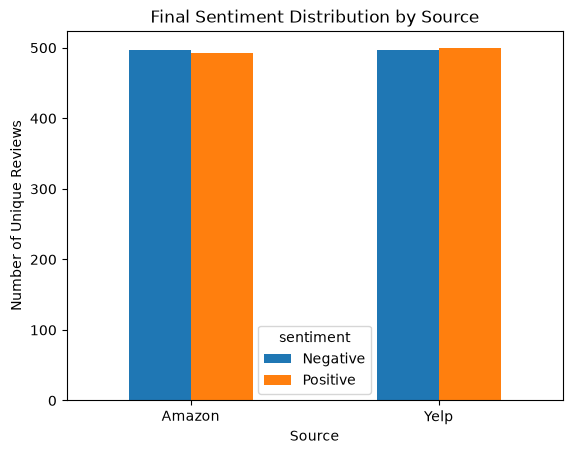

In [40]:
final_sentiment = pd.crosstab(
    feedback_clean["source"],
    feedback_clean["sentiment"]
)

final_sentiment.plot(kind="bar")

plt.title("Final Sentiment Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Number of Unique Reviews")
plt.xticks(rotation=0)

plt.show()

# Conclusion

This project analyzed customer feedback from Amazon and Yelp using Python and GenAI-assisted thematic analysis.

The original dataset contained 2,000 reviews. After identifying and removing 14 exact duplicate records, the final analysis dataset contained 1,986 unique reviews with no missing values or remaining duplicate records.

## Key Findings

### Amazon

Amazon customer feedback is primarily product-oriented.

The major negative themes include:
- Product usability and fit
- Audio and call quality
- Battery and charging
- Product reliability and durability
- Value for money
- Customer service/support

The major positive themes include:
- Product quality and performance
- Sound/audio quality
- Battery performance
- Compatibility and usefulness
- Value for money
- Overall satisfaction

### Yelp

Yelp customer feedback is primarily experience-oriented.

The major negative themes include:
- Food quality and taste
- Service and staff
- Waiting time
- Value and pricing
- Overall customer experience
- Atmosphere/location

The major positive themes include:
- Food quality and taste
- Service quality
- Atmosphere
- Value and pricing
- Menu selection
- Overall experience

## Business Takeaway

Customer-feedback strategies should be tailored to the type of business.

For product-focused feedback such as Amazon, organizations should prioritize product usability, performance, reliability, battery life and perceived value.

For experience-focused feedback such as Yelp, organizations should prioritize food quality, service, waiting time, value and the overall customer experience.

GenAI can help transform large amounts of unstructured customer feedback into structured themes and actionable insights. However, business decisions should combine review analysis with operational and financial data.

# Limitations

1. The dataset contains review text and sentiment labels but does not provide detailed financial or operational metrics.

2. Root causes identified in this project are evidence-based hypotheses rather than confirmed internal business causes.

3. Theme-supporting keyword counts are signals and should not be interpreted as exact semantic theme frequencies.

4. Individual reviews can mention multiple issues and therefore may belong to more than one theme.

5. The dataset represents the provided Amazon and Yelp reviews and may not represent all customers or all businesses on those platforms.

6. Business-impact and priority ratings are qualitative because revenue, customer lifetime value, churn, return rates and operational-cost data were not provided.

7. Recommendations should therefore be validated against real operational and financial data before implementation.

In [41]:
print("FINAL PROJECT CHECK")
print("=" * 40)

print("Final dataset size:", len(feedback_clean))
print("Missing values:", feedback_clean.isnull().sum().sum())
print("Remaining duplicates:", feedback_clean.duplicated().sum())
print("Positive reviews:", (feedback_clean["sentiment"] == "Positive").sum())
print("Negative reviews:", (feedback_clean["sentiment"] == "Negative").sum())

print("\nSource distribution:")
print(feedback_clean["source"].value_counts())

print("\nProject files created:")
print("- capstone_customer_feedback.csv")
print("- capstone_customer_feedback_clean.csv")
print("- negative_reviews_for_genai.csv")
print("- positive_reviews_for_genai.csv")

FINAL PROJECT CHECK
Final dataset size: 1986
Missing values: 0
Remaining duplicates: 0
Positive reviews: 992
Negative reviews: 994

Source distribution:
source
Yelp      996
Amazon    990
Name: count, dtype: int64

Project files created:
- capstone_customer_feedback.csv
- capstone_customer_feedback_clean.csv
- negative_reviews_for_genai.csv
- positive_reviews_for_genai.csv
